# Fuel Price Radar — report

Reads the SQL marts and renders the charts used in the README.
Prerequisites: a populated database and `python -m pipeline marts` applied.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()
engine = create_engine(os.environ["DATABASE_URL"])
IMG = Path("../docs/img")
IMG.mkdir(parents=True, exist_ok=True)

INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.edgecolor": BASE, "axes.linewidth": 1.0,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "text.color": INK, "axes.labelcolor": INK2,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.titlelocation": "left", "axes.titlesize": 13, "axes.titleweight": "bold",
    "font.size": 11, "legend.frameon": False,
})

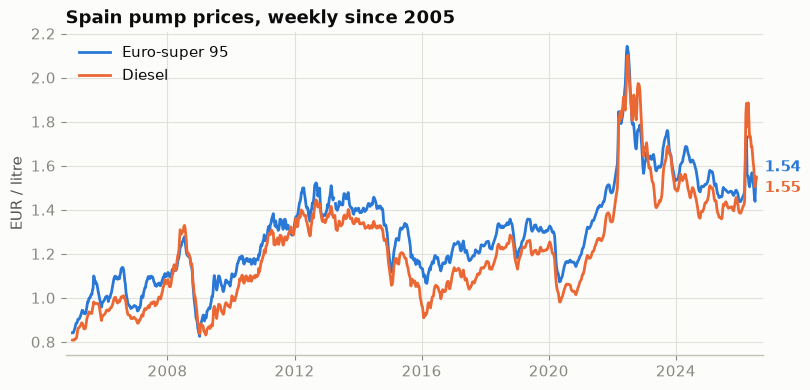

In [2]:
# 1. Spain pump prices since 2005, weekly (EU Oil Bulletin)
df = pd.read_sql(
    """SELECT price_date, category, price_eur FROM mart_price_history
       WHERE series = 'eu_bulletin' AND country = 'ES' ORDER BY price_date""",
    engine, parse_dates=["price_date"],
)
wide = df.pivot(index="price_date", columns="category", values="price_eur").astype(float)

fig, ax = plt.subplots(figsize=(9, 4.2))
for cat, color, label, dy in [("g95", BLUE, "Euro-super 95", 8), ("diesel", ORANGE, "Diesel", -8)]:
    ax.plot(wide.index, wide[cat], color=color, lw=2, label=label)
    last = wide[cat].dropna()
    ax.annotate(f"{last.iloc[-1]:.2f}", xy=(last.index[-1], last.iloc[-1]),
                xytext=(6, dy), textcoords="offset points", color=color,
                fontweight="bold", va="center")
ax.set_title("Spain pump prices, weekly since 2005")
ax.set_ylabel("EUR / litre")
ax.legend(loc="upper left")
ax.margins(x=0.01)
fig.savefig(IMG / "es_price_history.png")
plt.show()

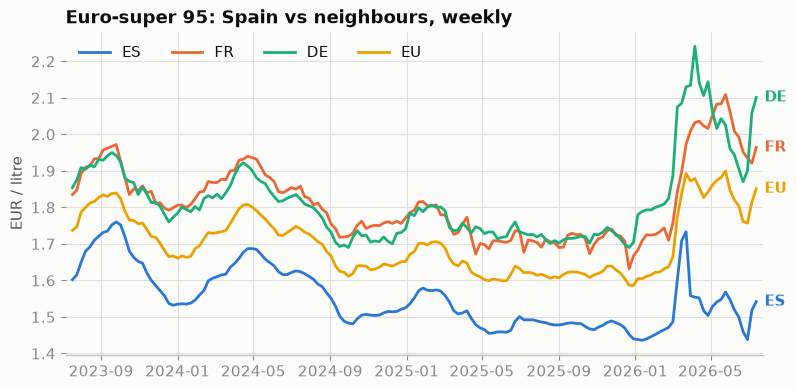

In [3]:
# 2. Spain vs neighbours and the EU average, last three years (G95)
df = pd.read_sql(
    """SELECT week, country, price_eur FROM mart_spain_vs_eu
       WHERE category = 'g95' AND country IN ('ES', 'FR', 'DE', 'EU')
         AND week >= (SELECT max(week) FROM mart_spain_vs_eu) - INTERVAL '3 years'
       ORDER BY week""",
    engine, parse_dates=["week"],
)
wide = df.pivot(index="week", columns="country", values="price_eur").astype(float)

fig, ax = plt.subplots(figsize=(9, 4.2))
for country, color in [("ES", BLUE), ("FR", ORANGE), ("DE", AQUA), ("EU", YELLOW)]:
    ax.plot(wide.index, wide[country], color=color, lw=2, label=country)
    last = wide[country].dropna()
    ax.annotate(country, xy=(last.index[-1], last.iloc[-1]), xytext=(6, 0),
                textcoords="offset points", color=color, fontweight="bold", va="center")
ax.set_title("Euro-super 95: Spain vs neighbours, weekly")
ax.set_ylabel("EUR / litre")
ax.legend(loc="upper left", ncols=4)
ax.margins(x=0.01)
fig.savefig(IMG / "spain_vs_neighbours.png")
plt.show()

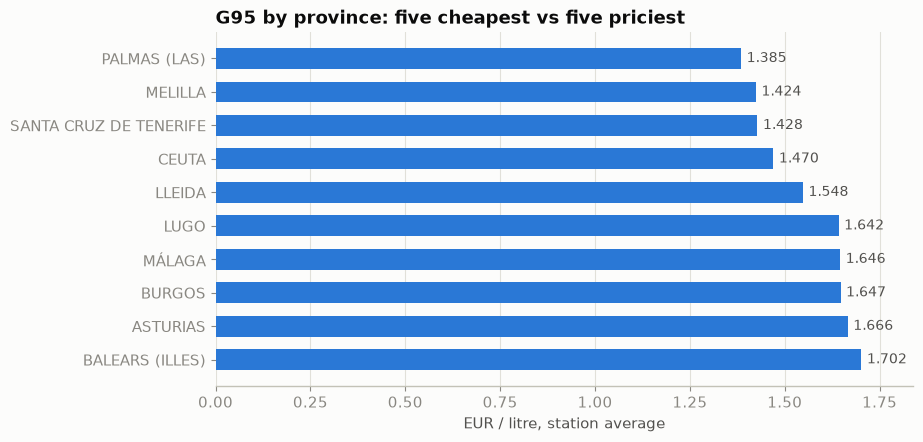

In [4]:
# 3. Cheapest and priciest provinces, latest day (G95, station average)
df = pd.read_sql(
    """SELECT name, avg_price_eur, n_stations FROM mart_regional_spread
       WHERE dimension = 'province' AND category = 'g95'
         AND price_date = (SELECT max(price_date) FROM mart_regional_spread)
       ORDER BY avg_price_eur""",
    engine,
)
edges = pd.concat([df.head(5), df.tail(5)]).astype({"avg_price_eur": float})

fig, ax = plt.subplots(figsize=(9, 4.6))
bars = ax.barh(edges["name"], edges["avg_price_eur"], color=BLUE, height=0.62)
ax.bar_label(bars, fmt="%.3f", padding=4, color=INK2, fontsize=10)
ax.invert_yaxis()
ax.set_title("G95 by province: five cheapest vs five priciest")
ax.set_xlabel("EUR / litre, station average")
ax.grid(axis="y", visible=False)
ax.margins(x=0.08)
fig.savefig(IMG / "provinces_spread.png")
plt.show()

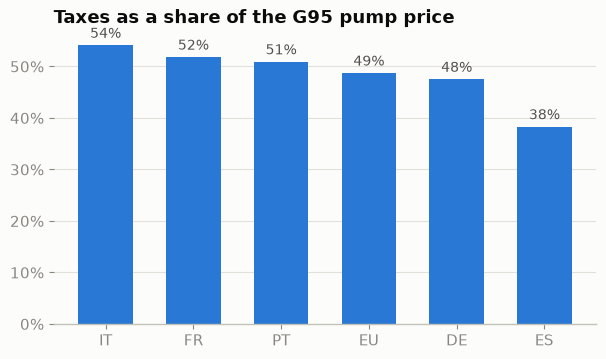

In [5]:
# 4. Taxes as a share of the pump price, latest week (G95)
df = pd.read_sql(
    """SELECT country, tax_share FROM mart_spain_vs_eu
       WHERE category = 'g95' AND week = (SELECT max(week) FROM mart_spain_vs_eu)
       ORDER BY tax_share DESC""",
    engine,
)
df = df.astype({"tax_share": float})

fig, ax = plt.subplots(figsize=(7, 3.8))
bars = ax.bar(df["country"], df["tax_share"], color=BLUE, width=0.62)
ax.bar_label(bars, fmt=lambda v: f"{v:.0%}", padding=3, color=INK2, fontsize=10)
ax.set_title("Taxes as a share of the G95 pump price")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.grid(axis="x", visible=False)
fig.savefig(IMG / "tax_share.png")
plt.show()